In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
import numpy as np

In [3]:
df= pd.read_csv('df_filtrado.csv')
df.head()

,Diag01,Diag02,Diag03,Diag04,Diag05,Diag06,Diag07,Diag08,Diag09,Diag10,...,Proced24,Proced25,Proced26,Proced27,Proced28,Proced29,Proced30,GRD,Edad,Sexo
0,K76.8 - Otras enfermedades especificadas del h...,K66.1 - Hemoperitoneo,"N18.5 - Enfermedad renal crónica, estadio 5",D64.9 - Anemia de tipo no especificado,E87.5 - Hiperpotasemia,E87.2 - Acidosis,J81 - Edema pulmonar,N17.8 - Otras insuficiencias renales agudas,J44.9 - Enfermedad pulmonar obstructiva crónic...,R41.0 - Desorientación no especificada,...,57.94 - SONDAJE URINARIO PERMANENTE,00.13 - INYECCION NESIRITIDE,00.17 - INFUSON AGENTE VASOPRESOR,99.04 - TRANSFUSION CONCENTRADO HEMATIES,99.18 - INYECCION ELECTROLITO,99.21 - INYECCION ANTIBIOTICO,99.23 - INYECCION ESTEROIDE,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...,61,0
1,T81.0 - Hemorragia y hematoma que complican un...,"Y83.2 - Operación quirúrgica con anastomosis, ...",S31.1 - Herida de la pared abdominal,S36.80 - Traumatismo de otros órganos intraabd...,W31.62 - Contacto traumático con otras maquina...,"J96.09 - Insuficiencia respiratoria aguda, Tip...",J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,"U07.1 - COVID-19, virus identificado","N39.0 - Infección de vías urinarias, sitio no ...",...,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,93.90 - RESPIRACION PRESION POSITIVA CONTINUA ...,99.15 - INFUSION PARENTERAL SUSTANCIA NUTRITIV...,96.59 - IRRIGACION HERIDA OTRA,45.13 - ESOFAGOGASTRODUODENOSCOPIA [EGD],041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...,30,0
2,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,J80 - Síndrome de dificultad respiratoria del ...,Z20.8 - Contacto con y exposición a otras enfe...,Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"T81.4 - Infección consecutiva a procedimiento,...",Y83.6 - Remoción de otro órgano (parcial) (total),"K85.9 - Pancreatitis aguda, no especificada",K65.0 - Peritonitis aguda,...,99.04 - TRANSFUSION CONCENTRADO HEMATIES,99.18 - INYECCION ELECTROLITO,99.19 - INYECCION ANTICOAGULANTE,99.21 - INYECCION ANTIBIOTICO,99.26 - INYECCION TRANQUILIZANTE,99.29 - INYECCION SUSTANCIA TERAPEUTICA O PROF...,93.01 - EVALUACION FUNCIONAL,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...,37,1
3,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,"J96.00 - Insuficiencia respiratoria aguda, Tip...","R50.9 - Fiebre, no especificada",R11 - Náusea y vómito,R05 - Tos,"M79.19 - Mialgia, sitio no especificado",R07.0 - Dolor de garganta,A09.9 - Gastroenteritis y colitis de origen no...,Z29.0 - Aislamiento,...,99.26 - INYECCION TRANQUILIZANTE,99.29 - INYECCION SUSTANCIA TERAPEUTICA O PROF...,93.01 - EVALUACION FUNCIONAL,93.09 - FISIOTERAPIA DIAGNOSTICA.OTRA,93.11 - EJERCICIO ASISTIDO,93.12 - EJERCICIO ACTIVO MUSCULOESQUELETICO OTRO,93.13 - EJERCICIO RESISTENCIA,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...,59,0
4,N17.0 - Insuficiencia renal aguda con necrosis...,K80.3 - Cálculo de conducto biliar con colangitis,"U07.1 - COVID-19, virus identificado","J96.09 - Insuficiencia respiratoria aguda, Tip...",I48.0 - Fibrilación auricular paroxística,R57.0 - Choque cardiogénico,A41.8 - Otras septicemias especificadas,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,Y95 - Afección nosocomial,U82.2 - Resistencia a Betalactamasas de amplio...,...,88.01 - TOMOGRAFIA AXIAL COMPUTERIZADA ABDOMEN,88.43 - ARTERIOGRAFIA ARTERIA PULMONAR,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,88.38 - TOMOGRAFIA AXIAL COMPUTERIZADA OTRA,87.44 - RADIOGRAFIA TORAX RUTINARIA,45.13 - ESOFAGOGASTRODUODENOSCOPIA [EGD],45.23 - COLONOSCOPIA FLEXIBLE,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...,77,1


In [7]:
encoder = LabelEncoder()
df["GRD_codificada"] = encoder.fit_transform(df["GRD"])

X = df.drop(columns=["GRD", "GRD_codificada"])
y = df["GRD_codificada"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [46]:
cat_features = X.select_dtypes(include=['object']).columns.tolist()

modelo = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    verbose=50,
    random_state=100
)

eval_set = (X_test, y_test)
modelo.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=eval_set,  
    early_stopping_rounds=50, 
    plot=False  
)

0:	learn: 1.8132216	test: 1.8031446	best: 1.8031446 (0)	total: 488ms	remaining: 8m 7s
50:	learn: 0.2069086	test: 0.1924294	best: 0.1924294 (50)	total: 29.9s	remaining: 9m 16s
100:	learn: 0.1434938	test: 0.1424159	best: 0.1424159 (100)	total: 1m 5s	remaining: 9m 42s
150:	learn: 0.1158084	test: 0.1252802	best: 0.1252802 (150)	total: 1m 43s	remaining: 9m 39s
200:	learn: 0.0969605	test: 0.1145204	best: 0.1145204 (200)	total: 2m 20s	remaining: 9m 18s
250:	learn: 0.0850077	test: 0.1084063	best: 0.1084063 (250)	total: 3m	remaining: 8m 57s
300:	learn: 0.0740833	test: 0.1034784	best: 0.1034784 (300)	total: 3m 37s	remaining: 8m 26s
350:	learn: 0.0656913	test: 0.0994846	best: 0.0994846 (350)	total: 4m 17s	remaining: 7m 57s
400:	learn: 0.0589670	test: 0.0974379	best: 0.0973259 (393)	total: 4m 56s	remaining: 7m 23s
450:	learn: 0.0538400	test: 0.0967002	best: 0.0967002 (450)	total: 5m 35s	remaining: 6m 48s
500:	learn: 0.0485009	test: 0.0935866	best: 0.0935866 (500)	total: 6m 13s	remaining: 6m 11s
55

dict_keys(['learn', 'validation'])


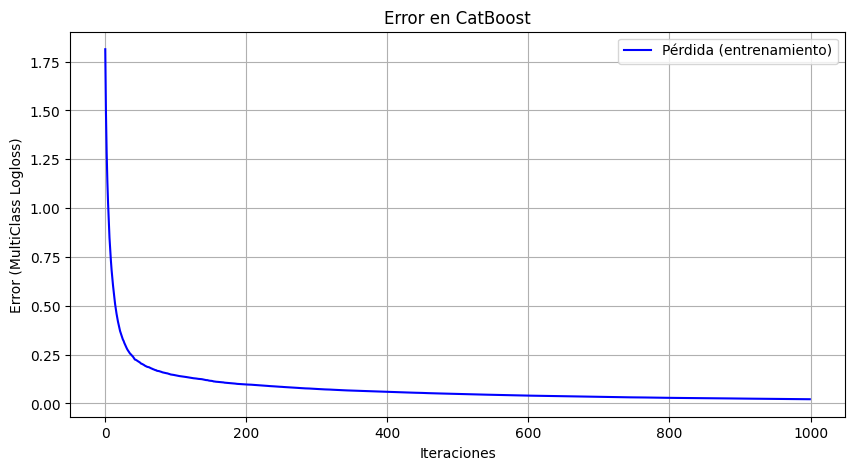

In [ ]:
historia = modelo.get_evals_result()
print(historia.keys())

train_loss = historia['learn']['MultiClass']

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label="Pérdida (entrenamiento)", color='blue')
plt.xlabel("Iteraciones")
plt.ylabel("Error (MultiClass Logloss)")
plt.title("Error en CatBoost")
plt.legend()
plt.grid(True)
plt.show()



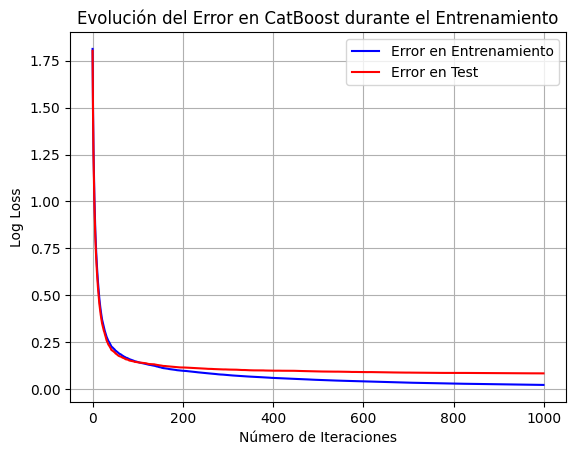

In [50]:
train_error = historia['learn']['MultiClass']
test_error = historia['validation']['MultiClass']

plt.plot(train_error, label="Error en Entrenamiento", color='blue')
plt.plot(test_error, label="Error en Test", color='red')
plt.xlabel("Número de Iteraciones")
plt.ylabel("Log Loss")
plt.title("Evolución del Error en CatBoost durante el Entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
y_pred = modelo.predict(X_test)


print("Reporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names= encoder.classes_))

Reporte de clasificación:

                                                                                        precision    recall  f1-score   support

                   041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC       0.94      0.96      0.95        50
                           044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC       0.96      0.93      0.95        57
                                             061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE       1.00      1.00      1.00        50
                                             071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA       1.00      0.98      0.99        63
                                                  134161 - MH TRASTORNOS DEL ANTEPARTO       0.96      1.00      0.98        65
                                                                   146101 - PH CESÁREA       0.93      0.99      0.96       163
                                                              146102 - PH CE

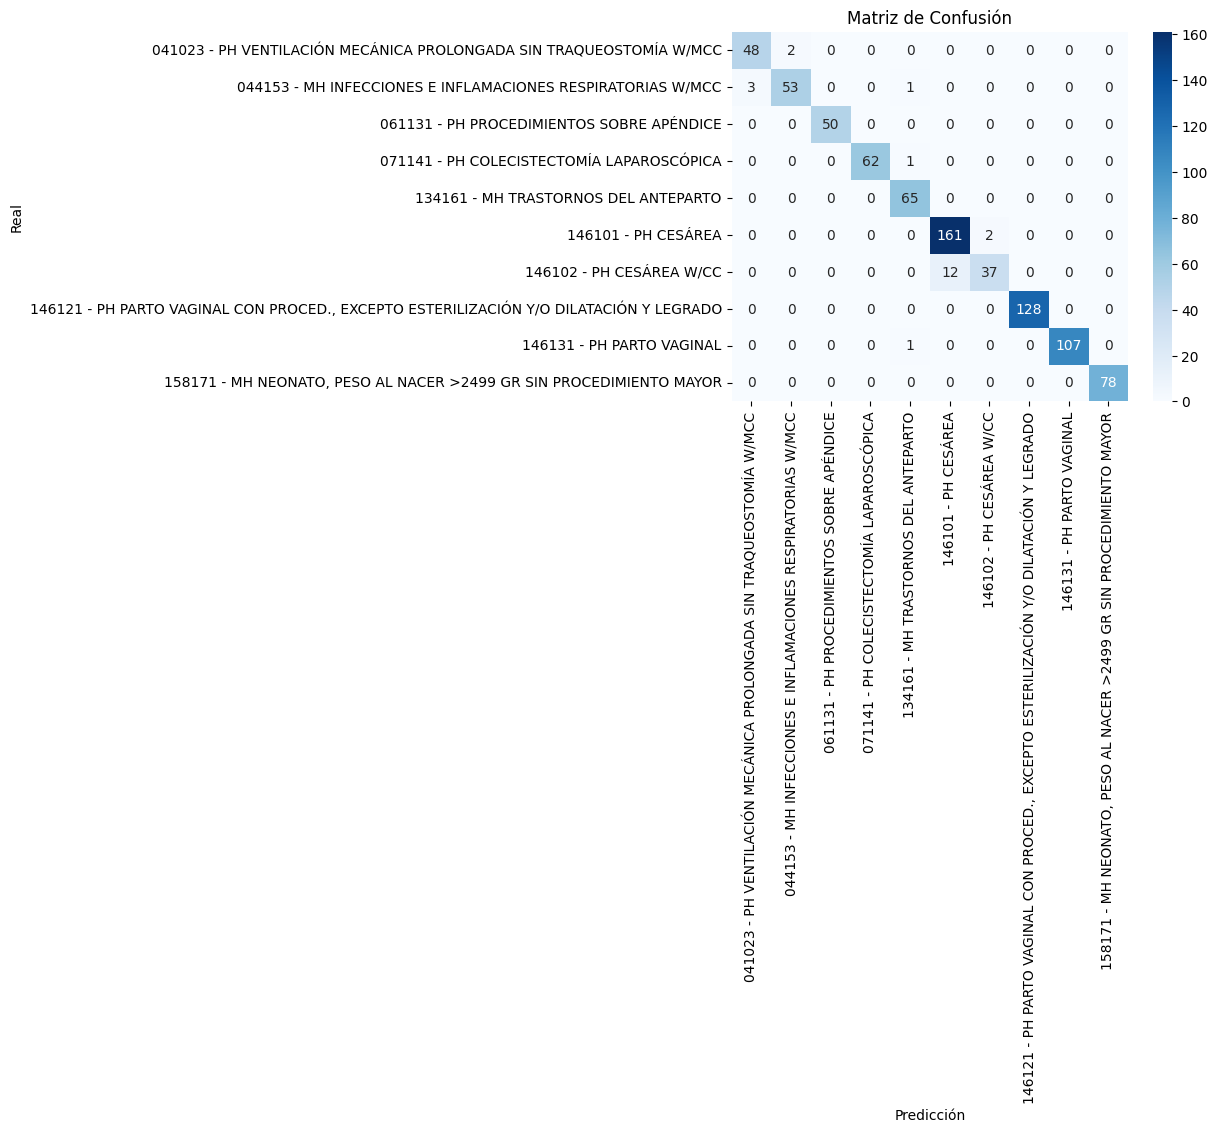

In [33]:
matriz = confusion_matrix(y_test, y_pred)
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

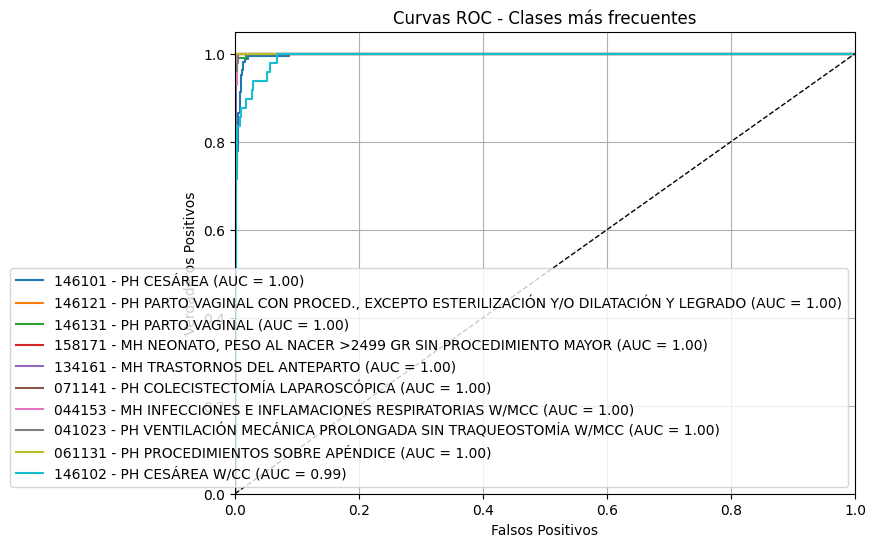

In [ ]:
y_proba = modelo.predict_proba(X_test)

#Binarizar etiquetas
y_test_bin = label_binarize(y_test, classes=list(range(len(encoder.classes_))))
unique, counts = np.unique(y_test, return_counts=True)
soporte = dict(zip(unique, counts))

#Tomar top 10 clases más frecuentes
top_clases = sorted(soporte.items(), key=lambda x: x[1], reverse=True)[:10]
top_indices = [clase[0] for clase in top_clases]

#Calcular curvas
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in top_indices:
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

#Graficar curvas 
plt.figure(figsize=(8, 6))
for i in top_indices:
    nombre = encoder.classes_[i]
    plt.plot(fpr[i], tpr[i], label=f"{nombre} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdaderos Positivos')
plt.title('Curvas ROC - Clases más frecuentes')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()